# Computational Linguistics: Practical Session 1 (7 October 2025): **solutions**

## Machine learning for NLP


Note: you are not required to submit any assignments for this practical session.

In this practical session, you will carry out a number of programming
exercises on machine learning for NLP, using Python. It will be helpful if you already know some basic Python (as provided in the first lectures of the course 'Scripting Languages', for example). But even you don't know anything about programming, you should be able to follow along with the examples.

For these exercises, we will make use of the interactive Python environment provided by Google Colab. The environment makes it possible to run Python code within your web browser. As an example, the code below computes the result of a sum, and outputs the result. Run the code by hovering over it, and pressing the play button in front.



In [1]:
result = 2 + 2
print(result)

4


### Introduction

In this practical session, we will explore machine learning models for
NLP applications; specifically, we will train statistical and neural network classifiers for
sentiment analysis on an English dataset of movie reviews (Maas et al., 2011).

First, download the archive that contains the dataset and unpack it, using the commands below:

In [2]:
!wget http://www.ccl.kuleuven.be/Courses/compling/data/review_dataset.tar.gz
!tar xzvf review_dataset.tar.gz

--2025-10-12 18:05:51--  http://www.ccl.kuleuven.be/Courses/compling/data/review_dataset.tar.gz
Resolving www.ccl.kuleuven.be (www.ccl.kuleuven.be)... 134.58.16.193
Connecting to www.ccl.kuleuven.be (www.ccl.kuleuven.be)|134.58.16.193|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 12846159 (12M) [application/x-gzip]
Saving to: â€˜review_dataset.tar.gzâ€™

     0K .......... .......... .......... .......... ..........  0% 1.19M 10s
    50K .......... .......... .......... .......... ..........  0% 3.53M 7s
   100K .......... .......... .......... .......... ..........  1% 2.01M 7s
   150K .......... .......... .......... .......... ..........  1% 14.3M 5s
   200K .......... .......... .......... .......... ..........  1% 2.13M 5s
   250K .......... .......... .......... .......... ..........  2% 6.38M 5s
   300K .......... .......... .......... .......... ..........  2% 13.1M 4s
   350K .......... .......... .......... .......... ..........  3% 3.58M 4s
   400K

A traditional machine learning pipeline for NLP applications generally consists of the following stages:

* data preprocessing (tokenization)
* feature extraction
* model training
* evaluation


We'll go through these stages step by step, using sentiment
classification as an application. As a dataset, we'll be using a set
of movie reviews in English, extracted from the website
[imdb.com](https://www.imdb.com). The dataset consists of the text of the review, as
well as a sentiment label (positive or negative). Note that
  the original ratings on IMDB range from 0 to 10
  stars. We will use binary classification instead. In our dataset,
  original reviews of $\leq 4$ stars are considered negative, while
  reviews of $\geq 7$ stars are considered positive. The training set is
divided into a training part (for training, 20000 reviews, i.e. 80%) and
test part (for evaluation, 5000 reviews, i.e. 20%). The dataset is
balanced, which means positive and negative instances are evenly
distributed in both train and test set.

### Preprocessing

First, we'll load the training set. To do so, we'll make use of the `pandas` library, which facilitates data manipulation. Issue the commands below:

In [3]:
import pandas as pd
train = pd.read_csv('reviews_train.csv', header=0, delimiter='\t', quoting=3)

We can now examine the data. Explore the dataset using the commands below. Note that negative sentiment is denoted by `0` and positive sentiment by `1`.


In [4]:
train.head()

,sentiment,review
0,0,an accurate review of nuremburg must consider ...
1,1,* * * spoilers * * * when undercover brooklyn ...
2,1,this movie is stuffed full of stock horror mov...
3,0,"if you have beloved actors , peter falk , rip ..."
4,0,"shazbot , is this embarrassing . in fact , her..."


In [5]:
print(train['review'][0])

an accurate review of nuremburg must consider the door to history inadvertently opened with the movie " valkyrie " ( tom cruise ) . " valkyrie " ( 2008 ) at long last tells the world there was a german resistance during world war two professionally organised with bureaucrats , military generals , soldiers and civilians who tried to over throw the nazi political regime , install a new chancellor , obtain peace and close the concentration camps . however , these unknown absolute heroes received no help at all from the allies who helped the french resistance just next door . history writers have used an institutionalised agenda ever since to conceal an allied evil which cost many tens of millions of lives with everyone conditioned to believe a deception that the german people completely supported the nazis and consequently deserved the 24 hour bombing genocide and " unconditional surrender " that was imposed on the germans .    the german enigma codes were broken by english scientists in 

Generally, we need to preprocess the dataset to be able to properly extract features from it. Within a computer, text is encoded as a continuous string of characters. For a computer, there is no difference between a space, a punctuation mark, or an alpha-numeric character. This means that a computer does not know about word or sentence boundaries. In order to analyze textual data within natural language processing applications, we first need to properly preprocess it. Note that our data has already been tokenized (i.e. words have been properly segmented), so we don't need to preprocess our data anymore.


### Feature extraction

Now it’s time to decide which features to use in our classifier. We’ll start with simple bag of words features. For this, we can make use of `scikit-learn`'s `CountVectorizer` object. `scikit-learn` (the model name of which is `sklearn`) is a well known Python library that implements a wide range of machine learning algorithms. `CountVectorizer` is part of `scikit-learn`'s feature extraction toolkit; it allows us to convert a collection of documents to a matrix of token counts (one feature vector for each review). We define the parameter `max_features` to be 500, which means only the 500 most frequent words will be taken into account. Once we have defined the `CountVectorizer` object, we can perform the actual feature extraction using the function `fit_transform`.

In [6]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(analyzer = 'word', max_features = 500) # extracts the 500 most frequent words
train_data_features = vectorizer.fit_transform(train['review'])

Using the command below, we can inspect the shape of the resulting matrix:

In [10]:
print(train_data_features.shape)

(20000, 500)


The output above tells us that we have a matrix of 20000 documents (reviews), by 500 word features. Each matrix cell represents the frequency of each of the 500 words within a particular review.

We can also inspect which are the 500 most frequent words that are used as features, using the command below:

In [11]:
vocab = vectorizer.get_feature_names_out()
print(vocab)

['10' 'able' 'about' 'absolutely' 'act' 'acting' 'action' 'actor' 'actors'
 'actress' 'actually' 'after' 'again' 'against' 'all' 'almost' 'along'
 'already' 'also' 'although' 'always' 'am' 'amazing' 'american' 'an' 'and'
 'another' 'any' 'anyone' 'anything' 'are' 'around' 'art' 'as' 'at'
 'audience' 'away' 'awful' 'back' 'bad' 'based' 'be' 'beautiful' 'because'
 'become' 'becomes' 'been' 'before' 'beginning' 'behind' 'being' 'believe'
 'best' 'better' 'between' 'big' 'bit' 'black' 'book' 'boring' 'both'
 'boy' 'brilliant' 'budget' 'but' 'by' 'ca' 'called' 'came' 'camera' 'can'
 'car' 'care' 'case' 'cast' 'certainly' 'character' 'characters' 'child'
 'children' 'cinema' 'classic' 'close' 'come' 'comedy' 'comes'
 'completely' 'could' 'couple' 'course' 'dark' 'day' 'days' 'dead' 'death'
 'definitely' 'despite' 'dialogue' 'did' 'different' 'direction'
 'director' 'do' 'does' 'doing' 'done' 'down' 'drama' 'during' 'dvd'
 'each' 'early' 'effects' 'either' 'else' 'end' 'ending' 'enjoy' 'enjoy

### Classification

`scikit-learn` contains many different implementations of classification algorithms. We’ll start with the classifier we examined during the lectures: a naive Bayes classifier. The naive Bayes classifier is represented by the `MultinomialNB` class. Once we have instantiated it, we can train it on our data using the `fit` function. Note that we are providing to the function both the features extracted for each review (`train_data_features`) and the correct sentiment label (`train['sentiment']`) for each review. In the training step, we need to provide our model with the correct answer.

In [12]:
from sklearn.naive_bayes import MultinomialNB
classifier = MultinomialNB()

classifier.fit(train_data_features, train['sentiment'])

MultinomialNB()

Our model has now been trained on the training set; we can now test its performance on the test set. First, we carry out the same preprocessing and feature extraction on the test set.

In [13]:
test = pd.read_csv('reviews_test.csv', header=0, delimiter='\t', quoting=3)
test_data_features = vectorizer.transform(test['review'])

Next, we can compute the performance on the test set.

In [14]:
score = classifier.score(test_data_features, test['sentiment'])
print(score)

0.777


#### Exercise 1



1.   What does the score represent?
2.   Look at the instances that were classified badly. Do you see why certain reviews are misclassified? Hint: use the function `predict`.



In [16]:
# the score represents the accuracy of the classifier: how many instances are
# predicted correctly (i.e., have the same label as the gold label in the test
# set?)

results = classifier.predict(test_data_features)

# the function `predict` provides predictions for each individual instance,
# which we can compare to the gold labels

# instances with incorrect predictions often contain ambivalent reviews, e.g.

print('Review #12:', test['review'][12], '\nGold label:', test['sentiment'][12], 'Predicted label:', results[12])

# review #12 talks about positive aspects within an overall negative review

Review #12: this is a little slow - moving for a horror movie , but the quality is better than you might expect for a director 's only effort on imdb . the camera work and lighting were both surprisingly good , and the acting  although variable  is better than is often found in indie genre flicks .   as the lead , robert field is rather stiff , which is especially unfortunate given that his character , claude , is the film 's narrator as well as the centre of its action . however , it was the entry of christopher ( brandon despain ) that i considered the turning point of this film  and not in a good way . a twist is introduced in a clumsy fashion , and slow - moving becomes drawn out and overly wordy .   on the up side , pete barker is consistently entertaining as father william . he 's the easy stand - out in what is a fairly ordinary offering . while the first half hour caught my interest , i ended up feeling quite disappointed in the way things played out . 
Gold label: 0 Predict

### K-fold cross validation

Usually, we will want to try out different parameters, in order to see what works best for our task. As such, we might experiment with:


* Different features
* Different classification algorithms
* Different model parameters


However, we have to be careful: we cannot use our test set over and over again, as we'll be optimizing our parameters for that particular test set (and run the risk of overfitting, which means we are not able to properly generalize to data we haven't trained on). For this reason, we need to make use of a **validation set**. However, our training set is already quite small; creating a separate validation set would give us even less training data. Fortunately, we don't have to create a separate set: we can use **k-fold cross validation**. The idea is the following:

* Break up data into $k$ (e.g. 10) parts (folds)
* For each fold

    * Current fold is used as temporary test set (called **validation** set)
    * Use other 9 folds as training data
    * Performance is computed on test fold

*  Average performance over 10 runs

A graphical representation of 10-fold cross validation is given below:


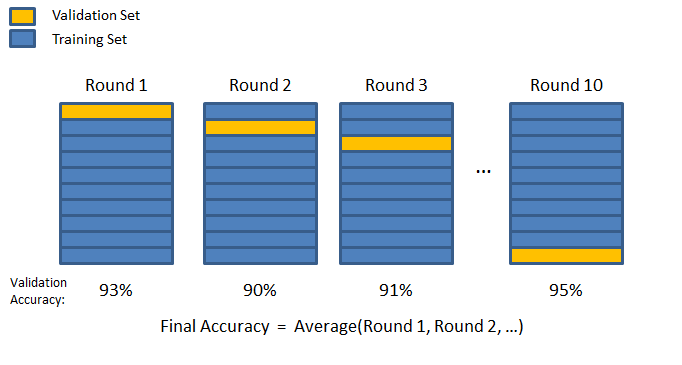

K-fold cross validation is implemented in the `StratifiedKFold` class. 'Stratified' means that we keep the number of positive and negative instances in the train and test set balanced throughout the cross-validation steps.

In [17]:
from sklearn.model_selection import StratifiedKFold

kf = StratifiedKFold(n_splits=10)
score_kfold = []

for n_fold, (train_indices, test_indices) in enumerate(kf.split(train_data_features, train['sentiment'])):
    X_train, X_test = train_data_features[train_indices], train_data_features[test_indices]
    y_train, y_test = train['sentiment'][train_indices], train['sentiment'][test_indices]

    classifier.fit(X_train, y_train)
    print('Score on fold' , n_fold, ':', classifier.score(X_test, y_test))
    score_kfold.append(classifier.score(X_test, y_test))

print('Average performance: ', sum(score_kfold) / len(score_kfold))

Score on fold 0 : 0.788
Score on fold 1 : 0.787
Score on fold 2 : 0.7835
Score on fold 3 : 0.7775
Score on fold 4 : 0.7955
Score on fold 5 : 0.792
Score on fold 6 : 0.758
Score on fold 7 : 0.791
Score on fold 8 : 0.7785
Score on fold 9 : 0.792
Average performance:  0.7843000000000001


#### Exercise 2

* Experiment with different feature sets
    * Experiment with n-grams instead of bag of words (hint: look at the arguments of CountVectorizer again in order to extract n-grams)

    * Change the number of vocabulary elements included in the model

* Experiment with different models

    * Try [a naive bayes classifier that uses binary features](https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.BernoulliNB.html) (word presence instead of word count)
    * Try [any other classifier included with scikit-learn](https://scikit-learn.org/stable/supervised_learning.html) (e.g. [decision trees](https://scikit-learn.org/stable/modules/tree.html), or [logistic regression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html#sklearn.linear_model.LogisticRegression)) How does it perform?

* When you’ve determined the best set of parameters (according to cross-validation), compute the performance on the test set

In [18]:
### YOUR CODE HERE
### You can either copy the code you want to adapt here, or you can just change
### the values in the existing code snippets above

from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# we use 20000 features, which can consist of unigrams (single words) or bigrams
vectorizer = CountVectorizer(analyzer = 'word',
                             max_features = 20000,
                             ngram_range=(1,2))


train_data_features = vectorizer.fit_transform(train['review'])
test_data_features = vectorizer.transform(test['review'])

vocab = vectorizer.get_feature_names_out()

# we'll test three classifiers using 5-fold cross validation

clf_NB = MultinomialNB()
clf_binNB = BernoulliNB()
clf_lr = LogisticRegression(max_iter=1000)

all_clf = [clf_NB, clf_binNB, clf_lr]

kf = StratifiedKFold(n_splits=5)
score_kfold = [ [] for i in range(len(all_clf))]

for n_fold, (train_indices, test_indices) in enumerate(kf.split(train_data_features, train['sentiment'])):
    X_train, X_test = train_data_features[train_indices], train_data_features[test_indices]
    y_train, y_test = train['sentiment'][train_indices], train['sentiment'][test_indices]

    for i, clf in enumerate(all_clf):
      clf.fit(X_train, y_train)
      print(clf, ': Score on fold' , n_fold, ':', clf.score(X_test, y_test))
      score_kfold[i].append(clf.score(X_test, y_test))

for i, clf in enumerate(all_clf):
  print(clf, ': Average performance: ', sum(score_kfold[i]) / len(score_kfold[i]))

# logistic regression works best according to cross-validation, so we'll choose
# this classifier to train on all our training data; we'll then test on the
# separate test data to see how our classifier performs

classifier = LogisticRegression(max_iter=1000)

classifier.fit(train_data_features, train['sentiment'])
score = classifier.score(test_data_features, test['sentiment'])
print('Final test score:', score)

MultinomialNB() : Score on fold 0 : 0.86
BernoulliNB() : Score on fold 0 : 0.86175
LogisticRegression(max_iter=1000) : Score on fold 0 : 0.87775
MultinomialNB() : Score on fold 1 : 0.852
BernoulliNB() : Score on fold 1 : 0.85925
LogisticRegression(max_iter=1000) : Score on fold 1 : 0.8815
MultinomialNB() : Score on fold 2 : 0.86725
BernoulliNB() : Score on fold 2 : 0.8745
LogisticRegression(max_iter=1000) : Score on fold 2 : 0.8825
MultinomialNB() : Score on fold 3 : 0.85125
BernoulliNB() : Score on fold 3 : 0.8655
LogisticRegression(max_iter=1000) : Score on fold 3 : 0.88
MultinomialNB() : Score on fold 4 : 0.85975
BernoulliNB() : Score on fold 4 : 0.86975
LogisticRegression(max_iter=1000) : Score on fold 4 : 0.884
MultinomialNB() : Average performance:  0.8580500000000001
BernoulliNB() : Average performance:  0.86615
LogisticRegression(max_iter=1000) : Average performance:  0.8811500000000001
Final test score: 0.8752


### Intrinsic model evaluation

Some models allow us to look at the most informative features. Using a logistic
regression, you can do the following:

In [19]:
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression(max_iter=1000)
classifier.fit(train_data_features, train['sentiment'])

allCoefficients = [(classifier.coef_[0,i], vocab[i]) for i in range(len(vocab))]

allCoefficients.sort()
allCoefficients.reverse()

#### Exercise 3

Examine the top and the bottom features of the `allCoefficients` list. Which features are the most informative?

In [20]:
### YOUR CODE HERE

print(allCoefficients[0:10])
print(allCoefficients[-10:-1])

[(1.3027662122606236, 'superb'), (1.2609408173892103, 'perfect'), (1.2418246553818137, 'definitely worth'), (1.1687357701959533, 'excellent'), (1.1368303523916092, 'refreshing'), (1.0990035873712314, 'enjoyable'), (1.0945745496598394, 'wonderful'), (1.045296685484385, '10 10'), (1.002027042713066, 'incredible'), (0.9765726024642408, 'rare')]
[(-1.2530500350046936, 'not worth'), (-1.2980155829387623, 'lacks'), (-1.3231436461631596, 'poorly'), (-1.3251755760919184, 'just not'), (-1.3953672841926201, 'boring'), (-1.443417978423314, 'disappointing'), (-1.5064664376242718, 'waste'), (-1.5161344871676206, 'awful'), (-1.5629803569697034, 'worst')]


### References

Andrew L. Maas, Raymond E. Daly, Peter T. Pham, Dan Huang, Andrew Y. Ng, and Christopher Potts. 2011. Learning Word Vectors for Sentiment Analysis. The 49th Annual Meeting of the Association for Computational Linguistics (ACL 2011).